<a href="https://colab.research.google.com/github/IrinAnd/Especializacion_DA_ITAcademy/blob/main/Sprint_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
from google.cloud import bigquery
from google.oauth2 import service_account
from google.colab import auth

auth.authenticate_user()
client = bigquery.Client(project='sprint3-analytics-irina')

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
sql_query = """
SELECT *
FROM `sprint3-analytics-irina.sprint3_silver.transactions_clean`
"""
df_transactions = client.query(sql_query).result().to_dataframe()

df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'])

df_transactions['transaction_timestamp'] = pd.to_datetime(df_transactions['transaction_timestamp'])

#NIVEL 1: Visualización Analítica Con Python.

## Ejercicio 1: Preguntas Analíticas Directas.

### PREGUNTA 1 - Evolución del número de transacciones.

Observamos un gráfico de líneas que muestra la evolución del número de transacciones mensuales desde 2015 hasta 2024. En el eje X se representa el tiempo (meses) y en el eje Y el número de transacciones. Se aprecia una tendencia general de crecimiento, con picos claros en 2019, 2021 y 2022, aunque con una volatilidad mensual importante. El volumen se mueve principalmente entre 800 y 880 transacciones. La versión de la IA es mejor: añade una media móvil que suaviza el ruido y facilita ver la tendencia real, además de incluir una leyenda más clara y profesional.



/tmp/ipykernel_917/759431491.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  datos['periodo'] = datos['transaction_timestamp'].dt.to_period('M').dt.to_timestamp()


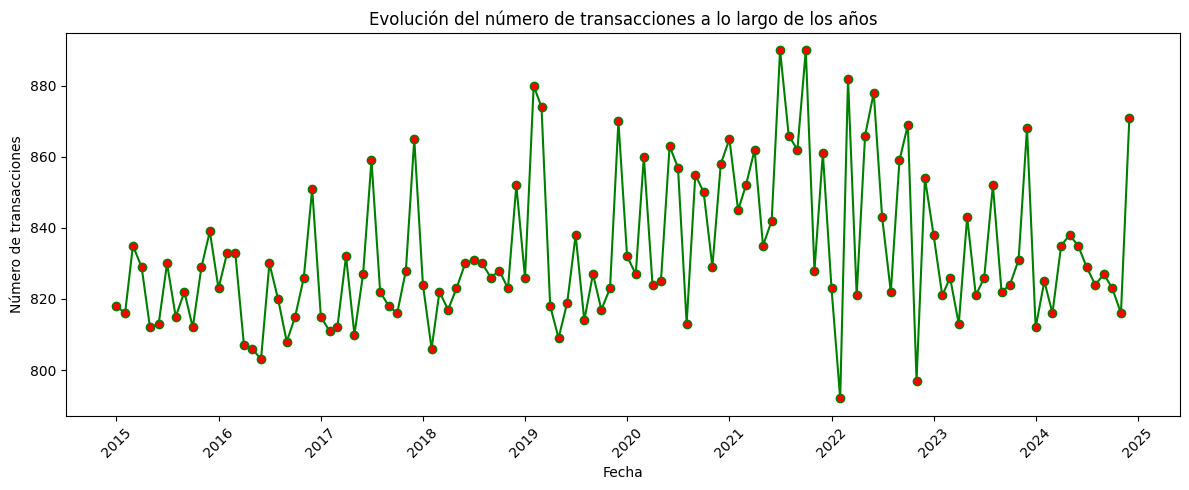

In [54]:

datos = df_transactions

datos['periodo'] = datos['transaction_timestamp'].dt.to_period('M').dt.to_timestamp()

evolucion = datos.groupby('periodo').size().reset_index(name='n_transacciones')

evolucion = evolucion.sort_values(by='periodo')

#Gráfico

plt.figure(figsize=(12, 5))
plt.plot(evolucion['periodo'], evolucion['n_transacciones'],
         color='green', marker='o', markerfacecolor='red')

plt.title('Evolución del número de transacciones a lo largo de los años')
plt.xlabel('Fecha')
plt.ylabel('Número de transacciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Generado por IA Gemini

### Visualización alternativa propuesta por IA.

Como alternativa, propongo una visualización que utilice `seaborn` para mejorar la estética y añadir una línea de tendencia suavizada (media móvil) para destacar mejor la tendencia subyacente, eliminando parte del ruido de las fluctuaciones mensuales.

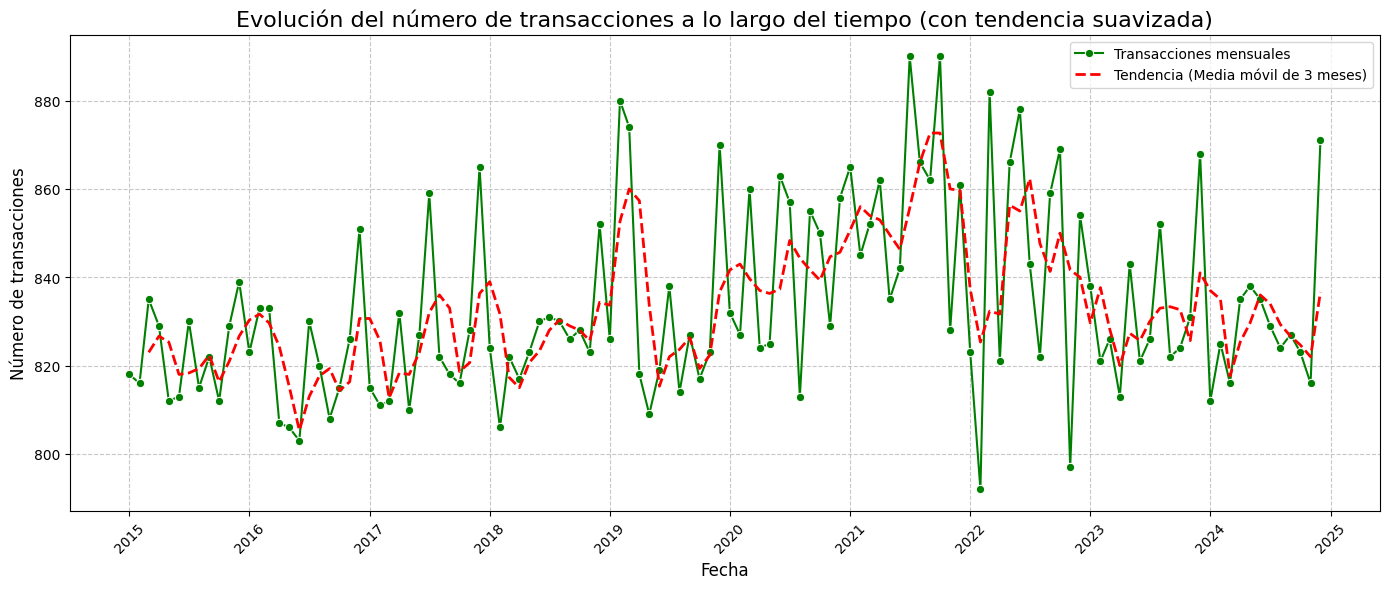

In [55]:
# Calcular una media móvil para suavizar la serie temporal
# Usamos una ventana de 3 meses para la media móvil
evolucion['n_transacciones_suavizadas'] = evolucion['n_transacciones'].rolling(window=3).mean()

plt.figure(figsize=(14, 6))

# Gráfico de líneas original
sns.lineplot(
    x='periodo',
    y='n_transacciones',
    data=evolucion,
    marker='o',
    color='green',
    label='Transacciones mensuales'
)

# Gráfico de líneas suavizado (media móvil)
sns.lineplot(
    x='periodo',
    y='n_transacciones_suavizadas',
    data=evolucion,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Tendencia (Media móvil de 3 meses)'
)

plt.title('Evolución del número de transacciones a lo largo del tiempo (con tendencia suavizada)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de transacciones', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### PREGUNTA 2 - Top usuarios por facturación.

El gráfico de barras horizontales muestra los 15 usuarios con mayor volumen de facturación. En el eje Y se encuentran los identificadores de usuario y en el eje X el importe total acumulado. Se observa una disminución gradual de la facturación a medida que bajamos en el ranking, lo que indica que existe un grupo reducido de usuarios de alto valor. La versión de la IA mejora ligeramente la estética (colores y rejilla),ambas versiones aportan la misma información analítica, la diferencia es principalmente visual.

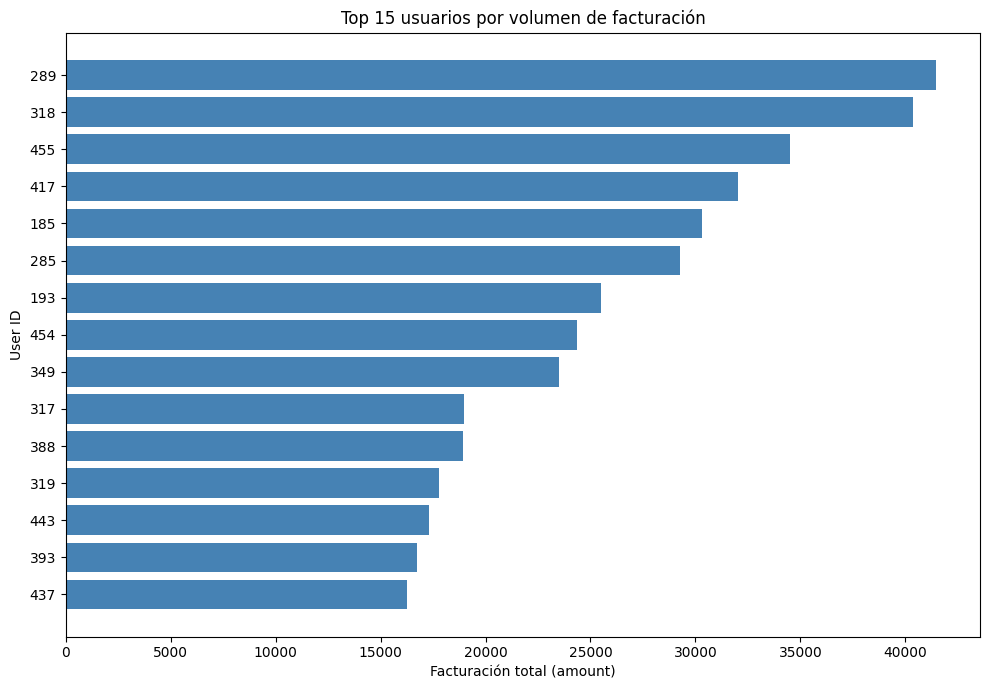

In [56]:

top_usuarios = datos.groupby('user_id')['amount'].sum().reset_index()


top_usuarios = top_usuarios.sort_values(by='amount', ascending=False)


top_15 = top_usuarios.head(15)

#4. Gráfico de barras horizontales
plt.figure(figsize=(10, 7))
plt.barh(top_15['user_id'].astype(str), top_15['amount'], color='steelblue')

plt.gca().invert_yaxis()

plt.title('Top 15 usuarios por volumen de facturación')
plt.xlabel('Facturación total (amount)')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()

Generado por IA Gemini

/tmp/ipykernel_917/3866427439.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


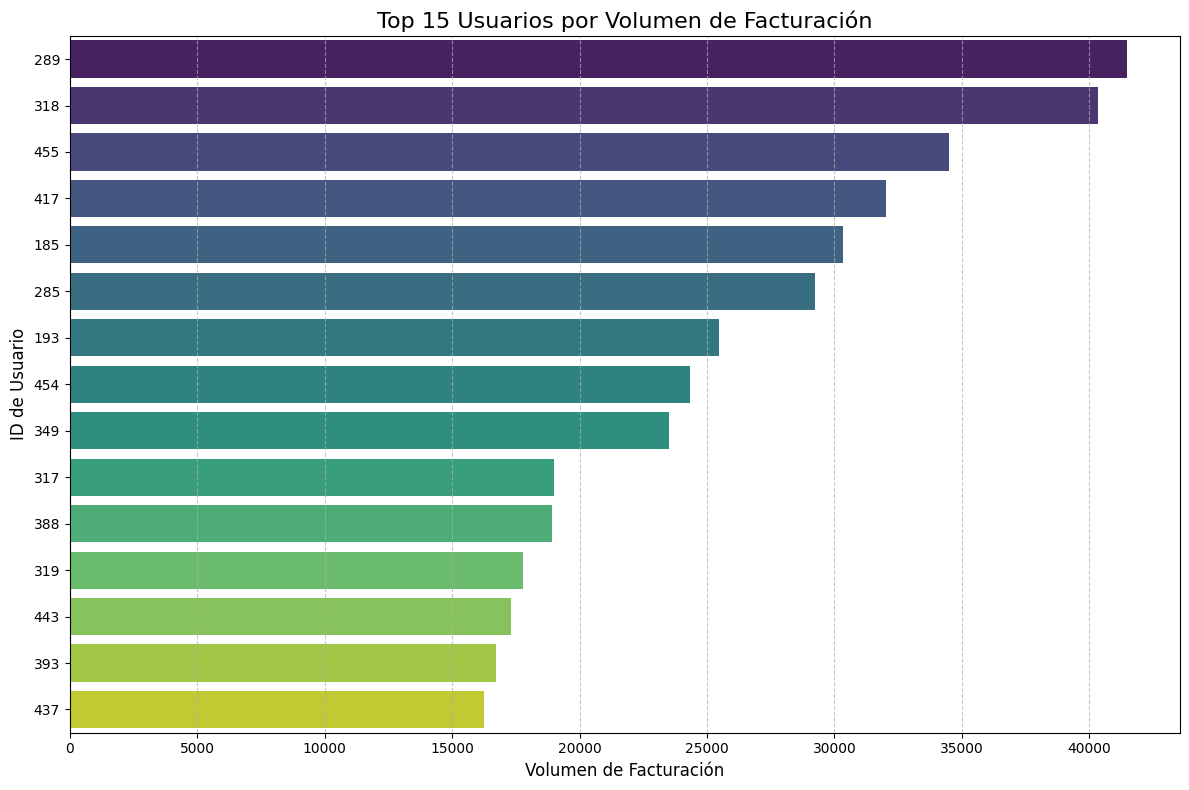


--- Interpretación de los resultados ---
Este gráfico de barras horizontales muestra los 15 usuarios que han generado el mayor volumen de facturación. Los usuarios están ordenados de mayor a menor volumen de facturación, lo que permite identificar rápidamente a los clientes más valiosos en términos de ingresos directos. Se observa que el usuario con ID '289' es el que más facturación ha generado, seguido de cerca por el usuario '318'. La distribución de las barras muestra una disminución gradual en el volumen de facturación a medida que descendemos en el ranking de usuarios principales.


In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# Los datos 'top_15' ya están preparados de la celda anterior.
# 'top_15' contiene user_id y amount para los 15 usuarios principales.

plt.figure(figsize=(12, 8))
sns.barplot(
    x='amount',
    y='user_id',
    data=top_15.astype({'user_id': str}),
    palette='viridis' # Una paleta de colores moderna
)

plt.title('Top 15 Usuarios por Volumen de Facturación', fontsize=16)
plt.xlabel('Volumen de Facturación', fontsize=12)
plt.ylabel('ID de Usuario', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Interpretación de los resultados ---")
print("Este gráfico de barras horizontales muestra los 15 usuarios que han generado el mayor volumen de facturación. Los usuarios están ordenados de mayor a menor volumen de facturación, lo que permite identificar rápidamente a los clientes más valiosos en términos de ingresos directos. Se observa que el usuario con ID '289' es el que más facturación ha generado, seguido de cerca por el usuario '318'. La distribución de las barras muestra una disminución gradual en el volumen de facturación a medida que descendemos en el ranking de usuarios principales.")

### PREGUNTA 3 - Distribución de importes por hora y estado.

El gráfico de cajas (boxplot) muestra la distribución del importe de las transacciones según la franja horaria y el estado (aceptada/rechazada). En el eje X se combinan las franjas horarias con el estado, y en el eje Y el importe. Se observa que la distribución de los importes es bastante similar entre franjas y entre estados, con presencia de valores atípicos en casi todos los grupos. La versión de la IA (violinplot) es superior porque muestra mejor la forma completa de la distribución y permite comparar de forma más visual las transacciones aceptadas y rechazadas.

<Figure size 1200x600 with 0 Axes>

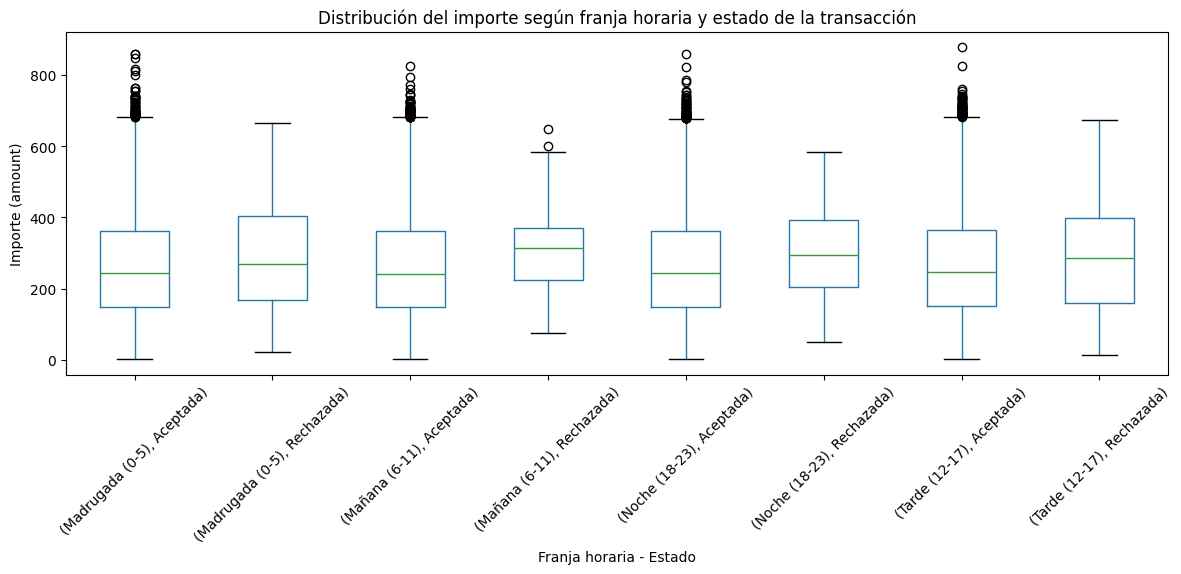

In [58]:


datos['hora'] = datos['transaction_timestamp'].dt.hour

def franja_horaria(hora):
    if 0 <= hora < 6:
        return 'Madrugada (0-5)'
    elif 6 <= hora < 12:
        return 'Mañana (6-11)'
    elif 12 <= hora < 18:
        return 'Tarde (12-17)'
    else:
        return 'Noche (18-23)'

datos['franja'] = datos['hora'].apply(franja_horaria)

datos['estado'] = datos['declined'].map({0: 'Aceptada', 1: 'Rechazada'})

#Gráfico.
plt.figure(figsize=(12, 6))
datos.boxplot(column='amount', by=['franja', 'estado'], figsize=(12, 6), grid=False)

plt.title('Distribución del importe según franja horaria y estado de la transacción')
plt.suptitle('')
plt.xlabel('Franja horaria - Estado')
plt.ylabel('Importe (amount)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Generado por IA Gemini

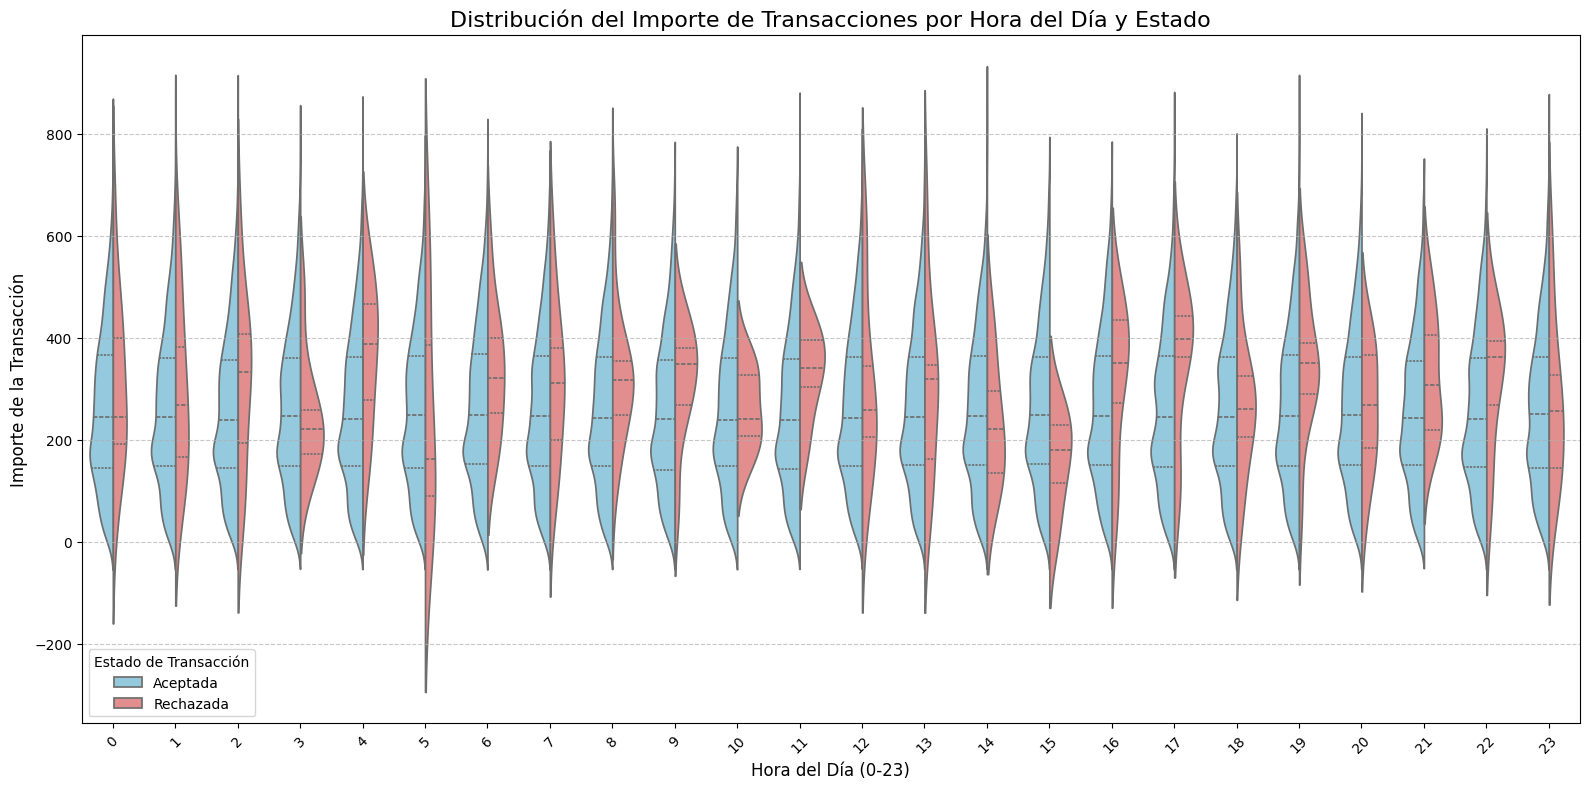

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear nueva columna con la hora del día a partir del timestamp
datos['hora'] = datos['transaction_timestamp'].dt.hour

# 2. Crear nueva columna para el estado de la transacción (aceptada/rechazada)
datos['estado'] = datos['declined'].map({0: 'Aceptada', 1: 'Rechazada'})

# 3. Utilizar un violinplot de seaborn
plt.figure(figsize=(16, 8))
sns.violinplot(
    data=datos,
    x='hora',
    y='amount',
    hue='estado',
    split=True, # Para comparar aceptadas y rechazadas lado a lado
    inner='quartile', # Para mostrar mediana y cuartiles
    palette={'Aceptada': 'skyblue', 'Rechazada': 'lightcoral'} # Colores para los estados
)

# Ajustes del gráfico
plt.title('Distribución del Importe de Transacciones por Hora del Día y Estado', fontsize=16)
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Importe de la Transacción', fontsize=12)
plt.xticks(rotation=45) # Rotar etiquetas del eje X para mejor lectura
plt.legend(title='Estado de Transacción')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### PREGUNTA 4 - Actividad por día de la semana

El gráfico de barras muestra el número de transacciones realizadas en cada día de la semana. En el eje X se encuentran los días y en el eje Y el número de transacciones. La actividad es muy estable a lo largo de la semana; las diferencias entre días son pequeñas (por eso se ha ajustado el eje Y). No se observa un día claramente dominante. La versión de la IA mejora la estética con colores y rejilla, pero al no limitar el eje Y las pequeñas diferencias se aprecian peor. En este caso, mi versión me resulta más útil analíticamente.

/tmp/ipykernel_917/3334641605.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  actividad = datos.groupby('dia_semana').size().reset_index(name='n_transacciones')


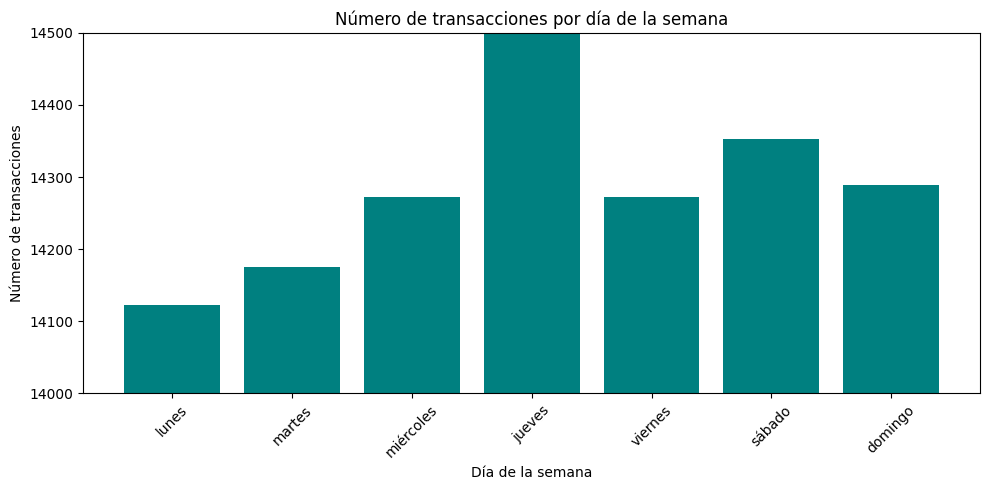

In [60]:


datos['dia_semana_ingles'] = datos['transaction_timestamp'].dt.day_name()

traduccion_dias = {
    'Monday': 'lunes',
    'Tuesday': 'martes',
    'Wednesday': 'miércoles',
    'Thursday': 'jueves',
    'Friday': 'viernes',
    'Saturday': 'sábado',
    'Sunday': 'domingo'
}

datos['dia_semana'] = datos['dia_semana_ingles'].map(traduccion_dias)

orden_dias = ['lunes', 'martes', 'miércoles', 'jueves', 'viernes', 'sábado', 'domingo']

datos['dia_semana'] = pd.Categorical(
    datos['dia_semana'],
    categories=orden_dias,
    ordered=True
)

actividad = datos.groupby('dia_semana').size().reset_index(name='n_transacciones')

actividad = actividad.sort_values(by='dia_semana')

# Gráfico de barras.
plt.figure(figsize=(10, 5))
plt.bar(actividad['dia_semana'], actividad['n_transacciones'], color='teal')
plt.ylim(14000, 14500)

plt.title('Número de transacciones por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Número de transacciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Generado por IA Gemini

/tmp/ipykernel_917/973219727.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


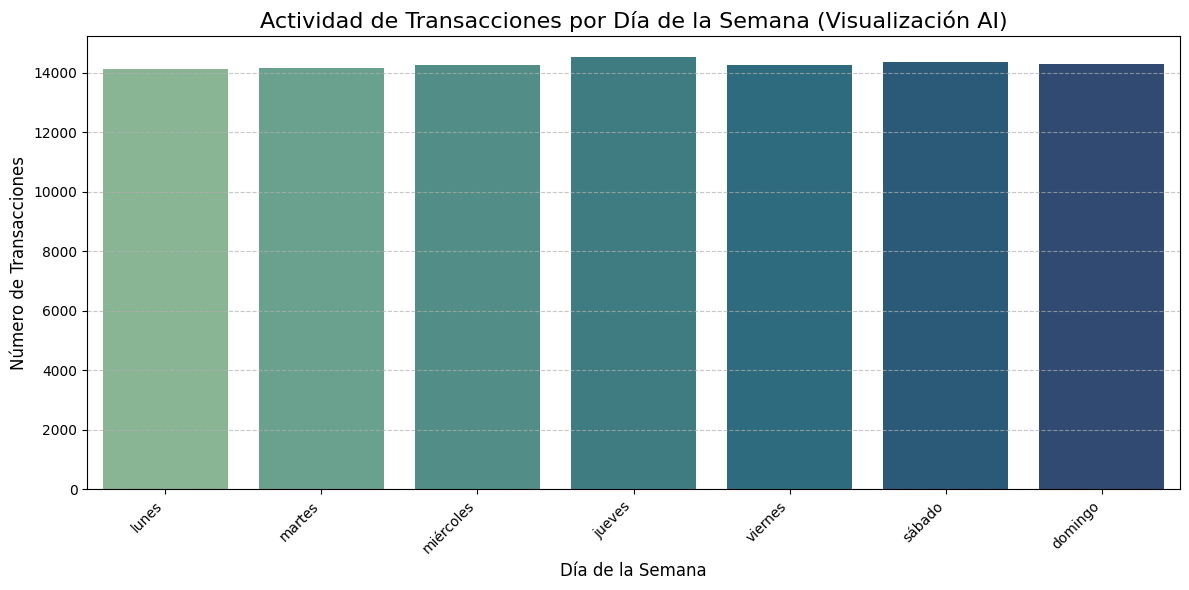

In [61]:
# --- PREGUNTA 4 - Actividad por día de la semana (Visualización Alternativa con IA) ---

# Los datos 'actividad' ya están preparados y ordenados por día de la semana.

plt.figure(figsize=(12, 6))
sns.barplot(
    x='dia_semana',
    y='n_transacciones',
    data=actividad,
    palette='crest' # Una paleta de colores de Seaborn que resalta bien las diferencias
)

plt.title('Actividad de Transacciones por Día de la Semana (Visualización AI)', fontsize=16)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Número de Transacciones', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir rejilla para facilitar la lectura de valores
plt.tight_layout()
plt.show()

## Ejercicio 2: Preguntas Analíticas Complejas.

In [62]:
sql_query_dos = """
SELECT *
FROM `sprint3-analytics-irina.sprint3_silver.companies_clean`
LIMIT 5
"""
df_companies = client.query(sql_query_dos).result().to_dataframe()
print(df_companies.columns.tolist())
df_companies.head()

['company_id', 'company_name', 'phone', 'email', 'country', 'website']


,company_id,company_name,phone,email,country,website
0,b-2282,Pretium Neque Corp.,07 77 48 55 28,eleifend.nec.malesuada@protonmail.couk,Australia,https://netflix.com/sub
1,b-2446,Risus Associates,04 25 82 54 31,egestas.ligula.nullam@google.edu,Australia,https://whatsapp.com/group/9
2,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9
3,b-2334,Amet Institute,06 33 40 21 33,nullam.lobortis.quam@outlook.net,Australia,https://nytimes.com/one
4,b-2498,Metus Vitae Associates,08 25 44 40 66,ad@protonmail.com,Australia,https://google.com/site


###Pregunta 1: Dependencia de países de compañías vendedoras

El gráfico de Pareto, barras + líneas, muestra que la facturación está bastante concentrada: los cinco primeros países (Suecia, Países Bajos, Reino Unido, Italia y Alemania) generan el 72 % de los ingresos totales. Aunque no existe una dependencia extrema de un único país, sí se observa una concentración moderada-alta en un grupo reducido de mercados europeos. Esto supone un riesgo de negocio, ya que cualquier problema en estos países podría afectar significativamente al volumen de ventas. Sería recomendable diversificar hacia otros mercados para reducir esta dependencia.

           country      amount  porcentaje  porcentaje_acumulado
12          Sweden  4251072.86   16.412438             16.412438
8      Netherlands  3890755.90   15.021336             31.433774
13  United Kingdom  3537120.34   13.656028             45.089802
7            Italy  3530071.81   13.628815             58.718617
5          Germany  3466842.93   13.384703             72.103320
4           France  1221902.17    4.717490             76.820810
14   United States  1069450.71    4.128909             80.949719
1          Belgium   922131.39    3.560142             84.509861
10          Norway   785907.27    3.034212             87.544073
6          Ireland   693054.42    2.675728             90.219801
9      New Zealand   685567.09    2.646821             92.866621
0        Australia   679418.68    2.623083             95.489704
2           Canada   542407.60    2.094114             97.583819
11           Spain   394609.21    1.523498             99.107316
3            China   2312

/tmp/ipykernel_917/1554366009.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(facturacion_pais['country'], rotation=45, ha='right')


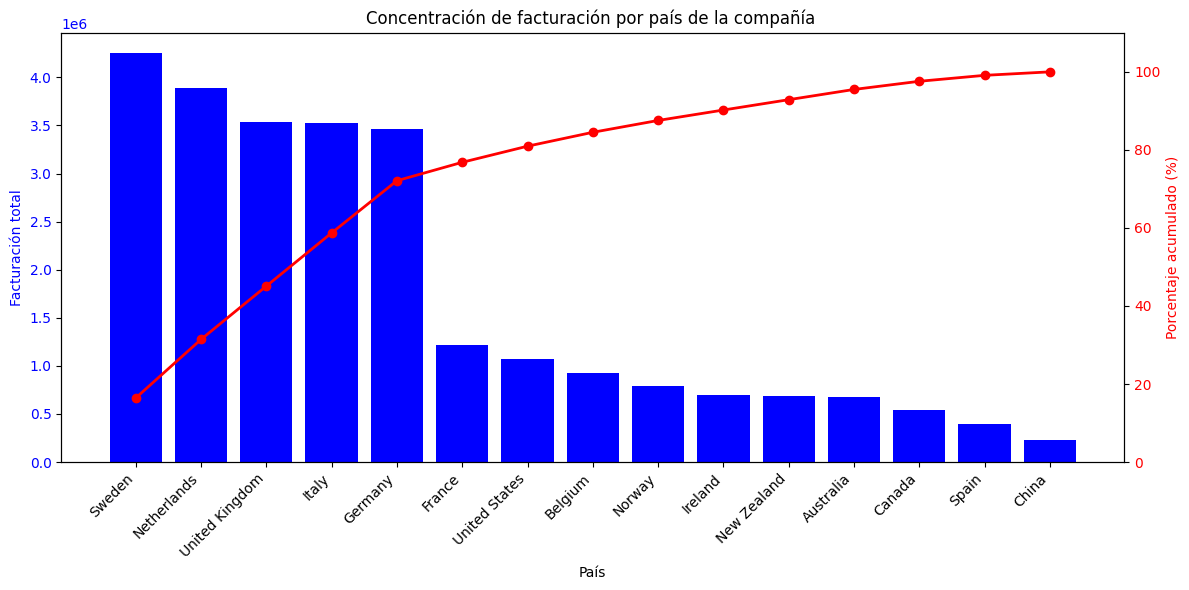

In [63]:

sql_transactions = """
SELECT *
FROM `sprint3-analytics-irina.sprint3_silver.transactions_clean`
"""
df_transactions = client.query(sql_transactions).result().to_dataframe()

sql_companies = """
SELECT *
FROM `sprint3-analytics-irina.sprint3_silver.companies_clean`
"""
df_companies = client.query(sql_companies).result().to_dataframe()


datos = pd.merge(
    df_transactions,
    df_companies,
    left_on='business_id',
    right_on='company_id',
    how='inner'
)


facturacion_pais = datos.groupby('country')['amount'].sum().reset_index()


facturacion_pais = facturacion_pais.sort_values(by='amount', ascending=False)


total = facturacion_pais['amount'].sum()
facturacion_pais['porcentaje'] = (facturacion_pais['amount'] / total) * 100

facturacion_pais['porcentaje_acumulado'] = facturacion_pais['porcentaje'].cumsum()

print(facturacion_pais)

#7. Gráfico Pareto.
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras de facturación
ax1.bar(facturacion_pais['country'], facturacion_pais['amount'], color='Blue')
ax1.set_xlabel('País')
ax1.set_ylabel('Facturación total', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(facturacion_pais['country'], rotation=45, ha='right')

# Línea de porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(facturacion_pais['country'], facturacion_pais['porcentaje_acumulado'],
         color='red', marker='o', linewidth=2)
ax2.set_ylabel('Porcentaje acumulado (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

plt.title('Concentración de facturación por país de la compañía ')
plt.tight_layout()
plt.show()

### Pregunta 2: Estacionalidad en las ventas

El gráfico es un heatmap que muestra la facturación mensual a lo largo de los años. En el eje X se representan los años (2015-2024) y en el eje Y los meses (1-12, de enero a diciembre). Los colores más oscuros indican mayor volumen de ventas y los más claros menor volumen. Se observa que no existe una estacionalidad fuerte y repetitiva todos los años: los picos de facturación aparecen en meses distintos según el año (marzo de 2019 y 2022, mayo-junio de 2022, diciembre como hemos ido viendo en los ejercicios). En general, la actividad se mantiene relativamente estable a lo largo del año, con variaciones moderadas, por lo que no se puede hablar de una estacionalidad clara y predecible.

año       2015       2016       2017       2018       2019       2020  \
mes                                                                     
1    208460.24  212357.82  209339.50  214646.54  210813.99  219397.63   
2    211179.56  214708.37  215198.48  209918.88  222423.06  211273.68   
3    221488.19  215368.86  208608.27  207377.32  243592.36  227262.89   
4    214675.51  210019.54  218995.78  205562.05  212679.25  213422.08   
5    215691.13  208713.77  204784.10  210126.23  208853.84  216073.84   
6    207759.31  208534.96  216287.92  217047.48  220443.02  212762.98   
7    218137.92  213505.12  218788.44  208823.33  211037.50  217751.47   
8    214170.06  212853.75  209566.97  207536.16  215470.42  210762.54   
9    204305.09  217441.50  211802.81  214016.87  210429.63  231158.60   
10   207329.31  213392.79  207924.36  219609.95  213913.65  221645.25   
11   206086.20  212567.32  219837.77  218591.71  209583.99  201522.40   
12   215907.55  216880.92  230320.82  213640.31  23

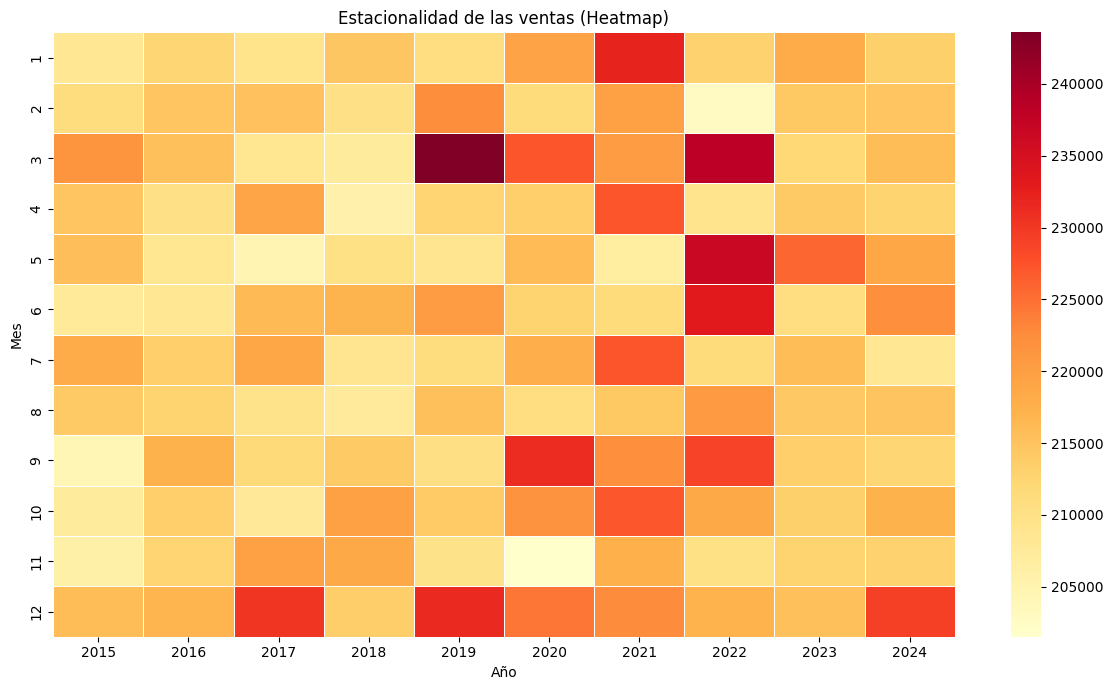

In [64]:

datos['transaction_timestamp'] = pd.to_datetime(datos['transaction_timestamp'])


datos['año'] = datos['transaction_timestamp'].dt.year
datos['mes'] = datos['transaction_timestamp'].dt.month


ventas_mensuales = datos.groupby(['año', 'mes'])['amount'].sum().reset_index()


tabla_pivot = ventas_mensuales.pivot(index='mes', columns='año', values='amount')


print(tabla_pivot)

#Gráfico Heatmap.
plt.figure(figsize=(12, 7))
sns.heatmap(
    tabla_pivot,
    annot=False,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title('Estacionalidad de las ventas (Heatmap)')
plt.xlabel('Año')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()